- Name : S Nirmal
- Course : Certified Data Scientist
- Batch ID : 08-JUL-24-CDS-BUN-021-WDM09-CHE
- Place : DataMites, Vadapalani, Chennai.

## i) EXPLORATORY DATA ANALYSIS:

In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [4]:
data = pd.read_excel('INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls')

In [5]:
data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


In [6]:
#checking missing values
data.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [8]:
data.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [9]:
data.shape

(1200, 28)

In [10]:
data.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

In [11]:
data.PerformanceRating.value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

In [12]:
#listing categorical variables
categ=data.select_dtypes(include='object')
list(categ.columns)

['EmpNumber',
 'Gender',
 'EducationBackground',
 'MaritalStatus',
 'EmpDepartment',
 'EmpJobRole',
 'BusinessTravelFrequency',
 'OverTime',
 'Attrition']

In [13]:
#listing numerical variables
num=data.select_dtypes(exclude='object')
list(num.columns)

['Age',
 'DistanceFromHome',
 'EmpEducationLevel',
 'EmpEnvironmentSatisfaction',
 'EmpHourlyRate',
 'EmpJobInvolvement',
 'EmpJobLevel',
 'EmpJobSatisfaction',
 'NumCompaniesWorked',
 'EmpLastSalaryHikePercent',
 'EmpRelationshipSatisfaction',
 'TotalWorkExperienceInYears',
 'TrainingTimesLastYear',
 'EmpWorkLifeBalance',
 'ExperienceYearsAtThisCompany',
 'ExperienceYearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'PerformanceRating']

## ii) UNI, BI, MULTI VARIATE ANALYSIS:

### Insight 1 : Department wise performances

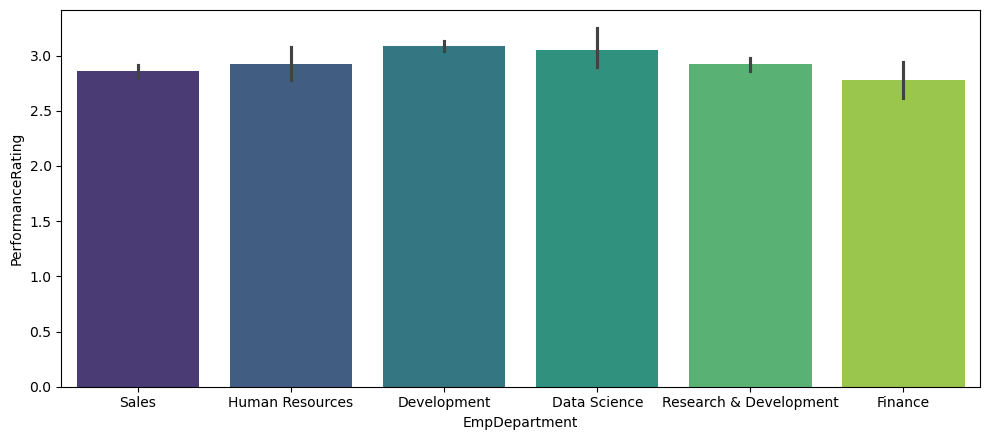

In [16]:
plt.figure(figsize=(10,4.5))
sns.barplot(x=data['EmpDepartment'],y=data['PerformanceRating'],palette='viridis')
plt.tight_layout()

<Axes: xlabel='count', ylabel='EmpDepartment'>

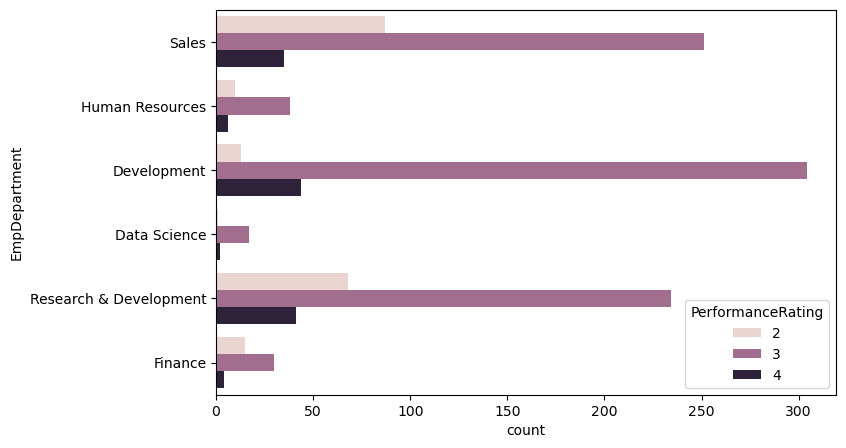

In [17]:
plt.figure(figsize = (8,5))
sns.countplot(y= data.EmpDepartment,hue = data.PerformanceRating)

In [18]:
#mean of all the departments
data.groupby(by='EmpDepartment')['PerformanceRating'].mean()

EmpDepartment
Data Science              3.050000
Development               3.085873
Finance                   2.775510
Human Resources           2.925926
Research & Development    2.921283
Sales                     2.860590
Name: PerformanceRating, dtype: float64

In [19]:
data.groupby(by='EmpDepartment')['PerformanceRating'].value_counts()

EmpDepartment           PerformanceRating
Data Science            3                     17
                        4                      2
                        2                      1
Development             3                    304
                        4                     44
                        2                     13
Finance                 3                     30
                        2                     15
                        4                      4
Human Resources         3                     38
                        2                     10
                        4                      6
Research & Development  3                    234
                        2                     68
                        4                     41
Sales                   3                    251
                        2                     87
                        4                     35
Name: count, dtype: int64

In [20]:
DataScience = data[data.EmpDepartment == 'Data Science']
DataScience.shape

(20, 28)

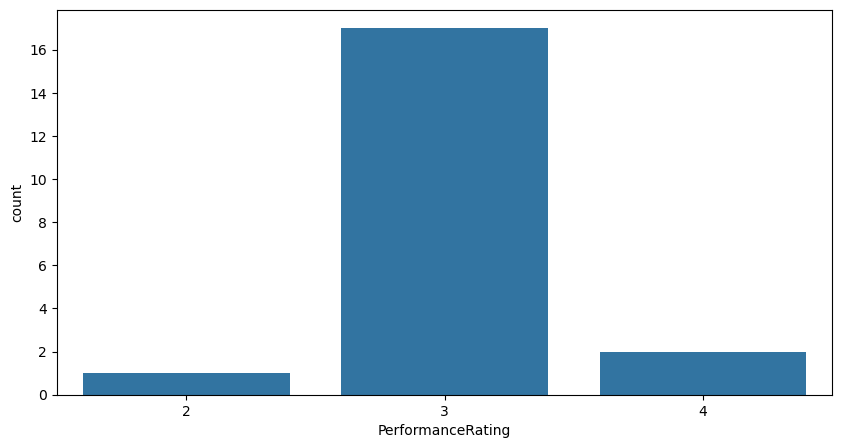

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(x="PerformanceRating", data=DataScience);
plt.show()
# PerformanceRating 3 is more for DataScience Department and PerformanceRating 2 is less for DataScience Department

In [22]:
Development = data[data.EmpDepartment == 'Development']
Development.shape

(361, 28)

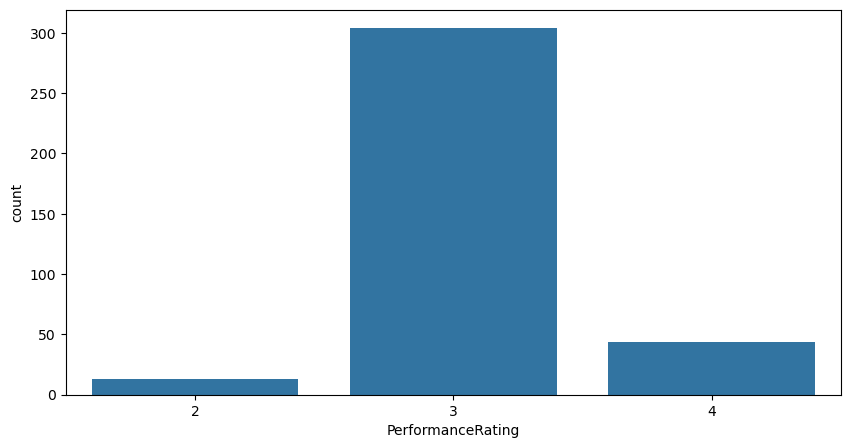

In [23]:
plt.figure(figsize=(10,5))
sns.countplot(x="PerformanceRating", data=Development);
plt.show()
# PerformanceRating 3 is more for Development Department and PerformanceRating 2 is less for Development Department

In [24]:
Finance = data[data.EmpDepartment == 'Finance'] 
Finance.shape

(49, 28)

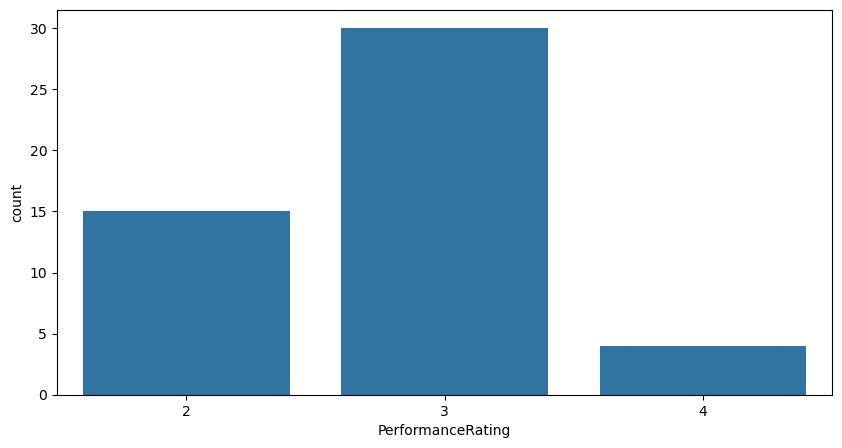

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(x="PerformanceRating", data=Finance);
plt.show()
# PerformanceRating 3 is more for Finance Department and PerformanceRating 4 is less for Finance Department

In [26]:
Human_Resources = data[data.EmpDepartment == 'Human Resources'] 
Human_Resources.shape

(54, 28)

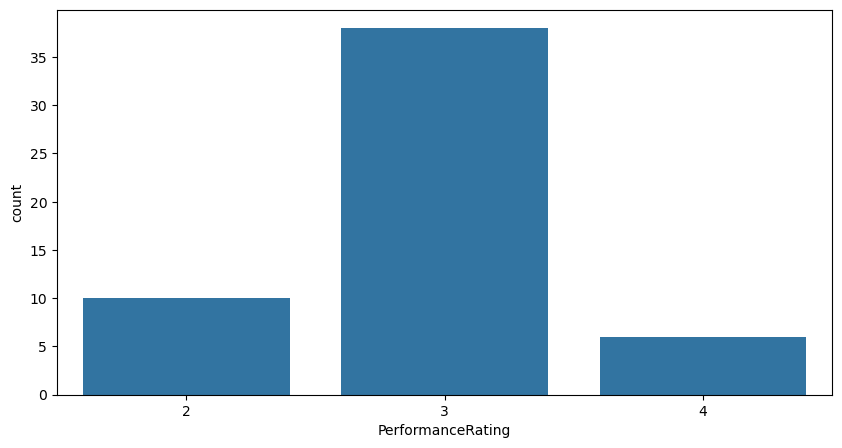

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(x="PerformanceRating", data=Human_Resources);
plt.show()
# PerformanceRating 3 is more for Human_Resources Department and PerformanceRating 4 is less for Human_Resources Department

In [28]:
Research_Development = data[data.EmpDepartment == 'Research & Development'] 
Research_Development.shape

(343, 28)

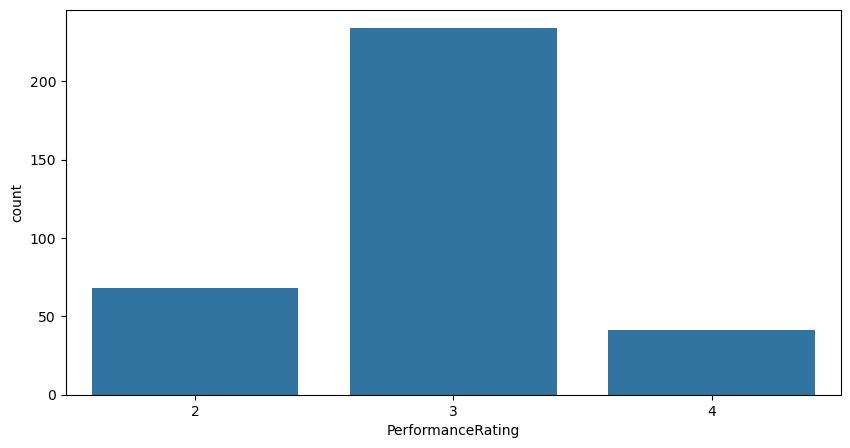

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(x="PerformanceRating", data=Research_Development);
plt.show()
# PerformanceRating 3 is more for Research_Development Department and PerformanceRating 4 is less for Research_Development Department

In [30]:
sales = data[data.EmpDepartment == 'Sales'] 
sales.shape

(373, 28)

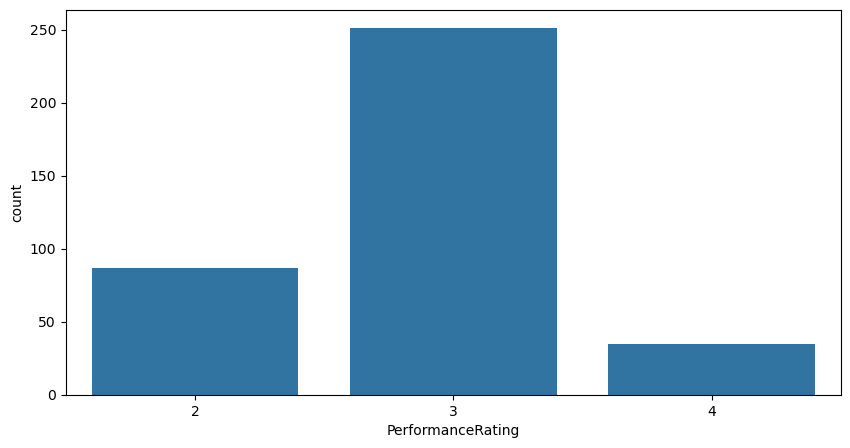

In [31]:
plt.figure(figsize=(10,5))
sns.countplot(x="PerformanceRating", data=sales);
plt.show()
# PerformanceRating 3 is more for sales Department and PerformanceRating 4 is less for sales Department

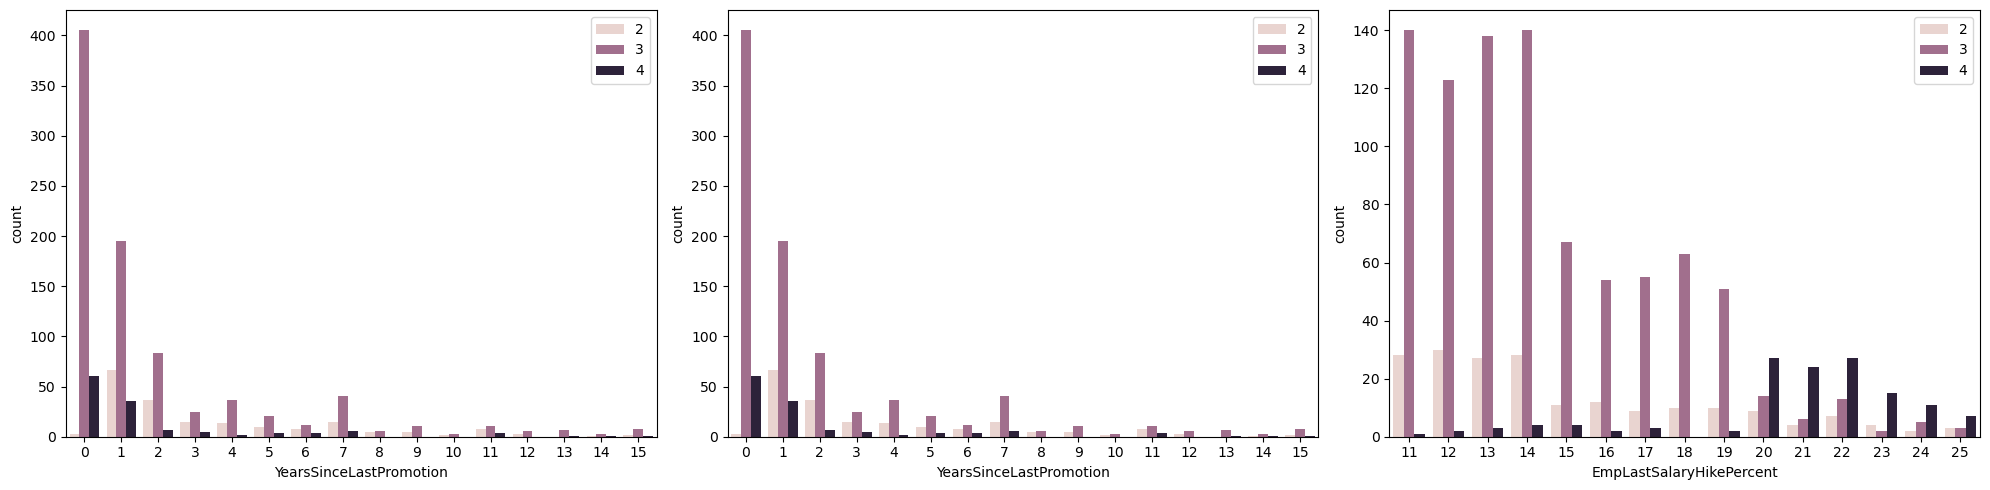

In [32]:
def plots(data):
    plt.figure(figsize=(20,5))
    plt.subplot(1,3,1)
    sns.countplot(x=data.YearsSinceLastPromotion, hue = data.PerformanceRating)
    plt.legend(loc = 'best')
    plt.subplot(1,3,2)
    sns.countplot(x=data.YearsSinceLastPromotion, hue = data.PerformanceRating)
    plt.legend(loc = 'best')
    plt.subplot(1,3,3)     
    sns.countplot(x=data.EmpLastSalaryHikePercent, hue = data.PerformanceRating)
    plt.legend(loc = 'best')
    plt.tight_layout()
    plt.show()
plots(data)

Filtering the DataFrame to only include rows of the corresponding data for better analysis report by giving the variables with boolean mask.

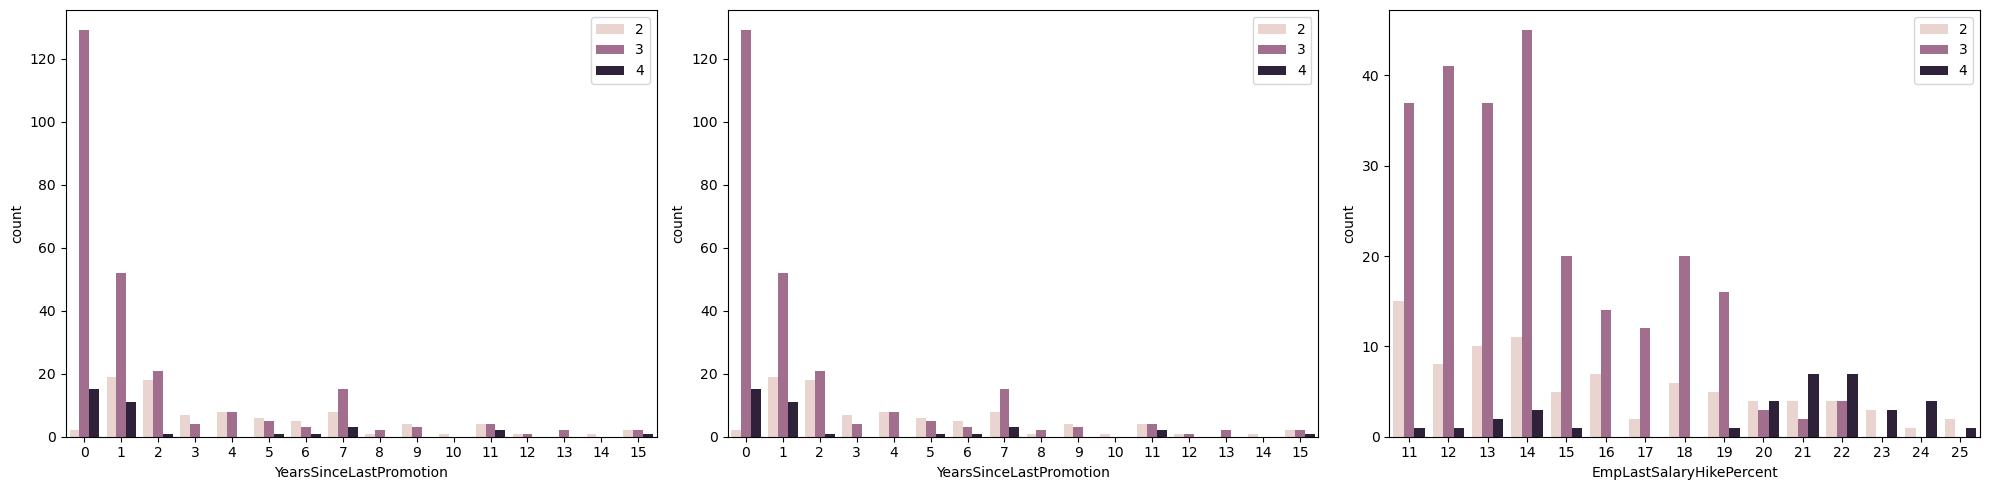

In [34]:
Sales = data[data.EmpDepartment == 'Sales']
plots(Sales)

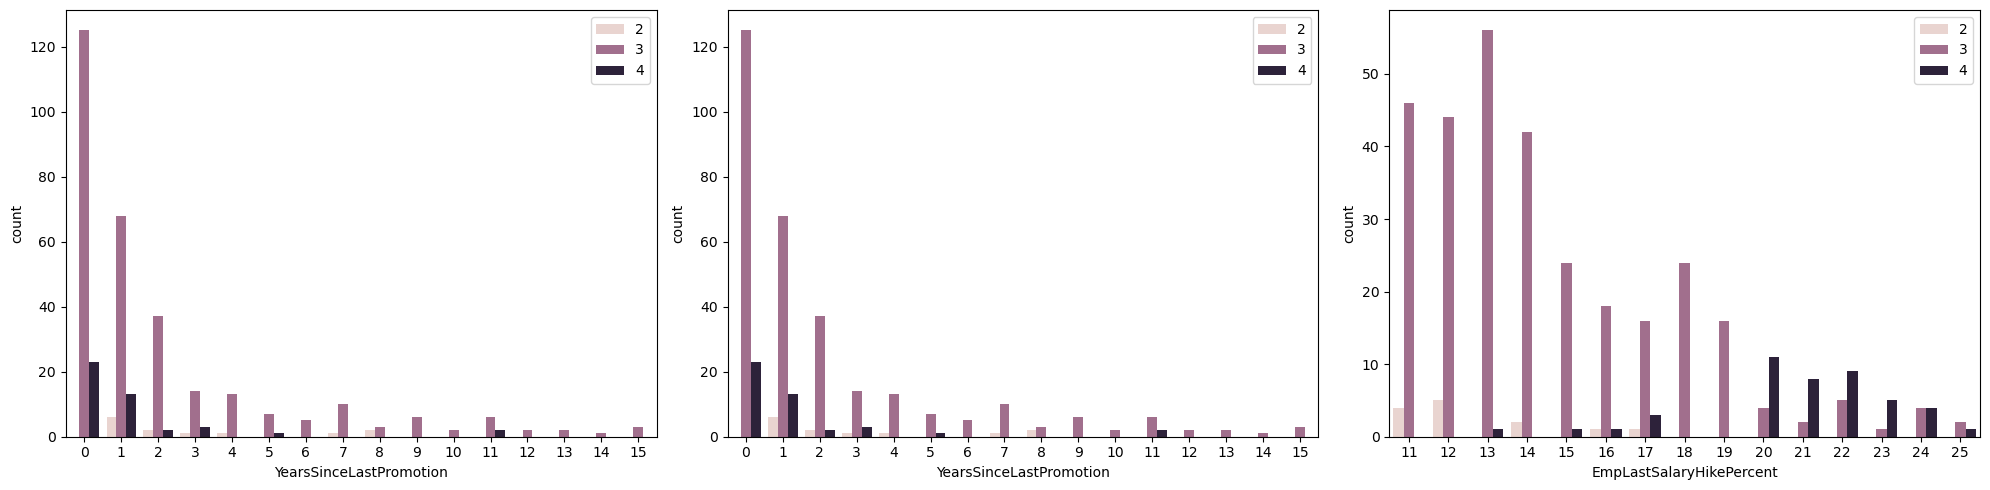

In [35]:
plots(Development)

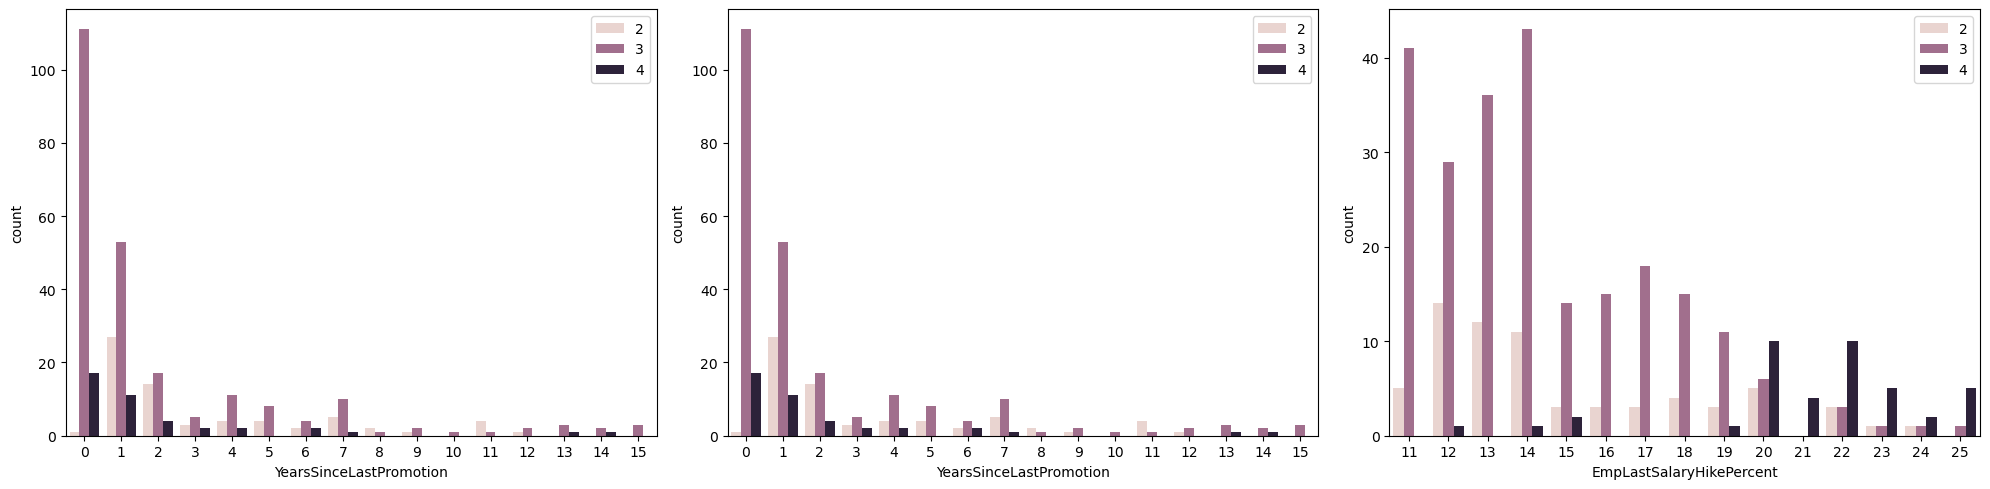

In [36]:
redev = data[data.EmpDepartment == 'Research & Development']
plots(redev)

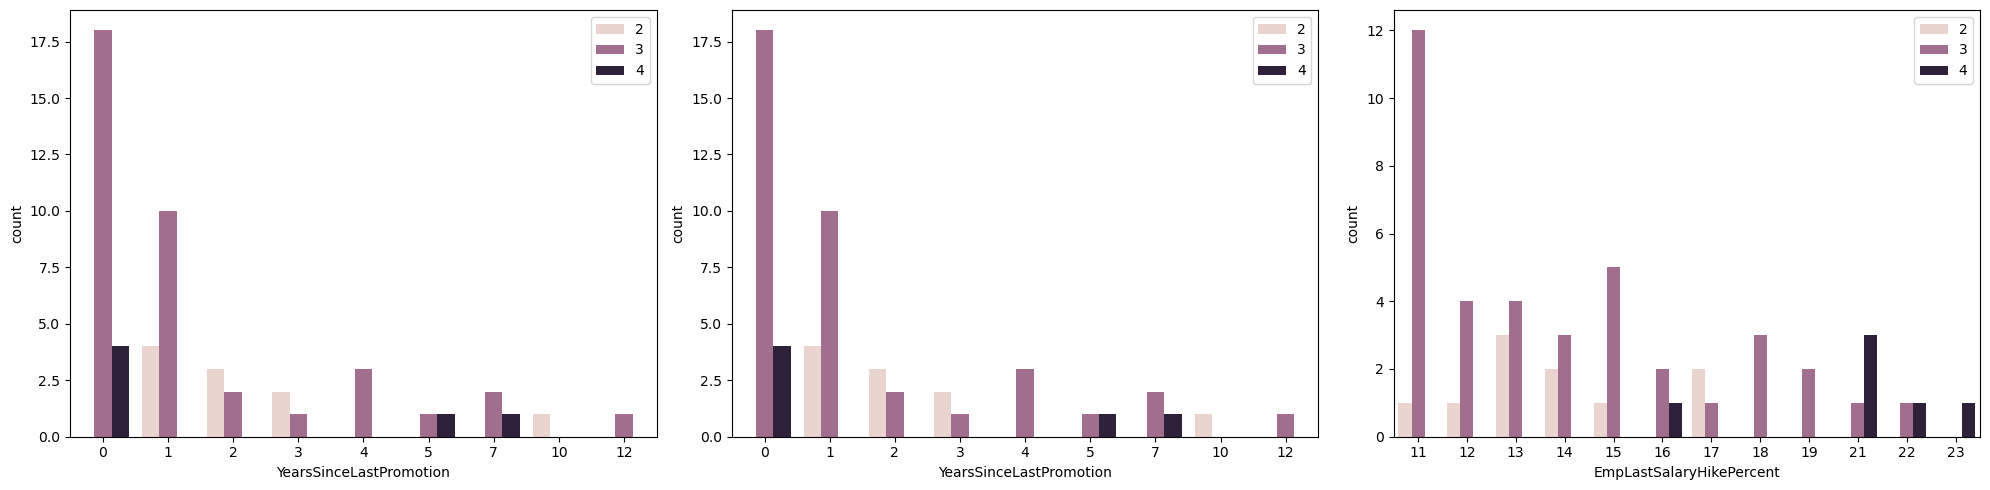

In [37]:
hr = data[data.EmpDepartment == 'Human Resources']
plots(hr)

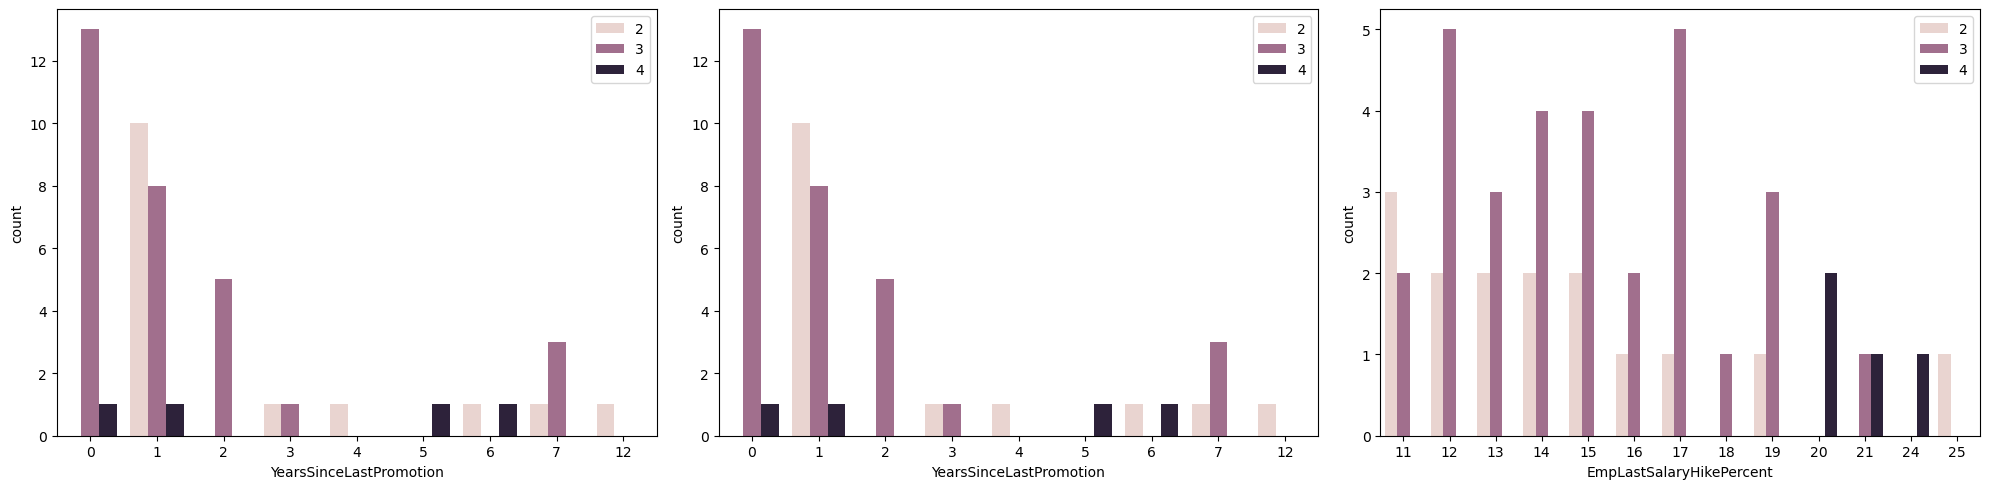

In [38]:
plots(Finance)

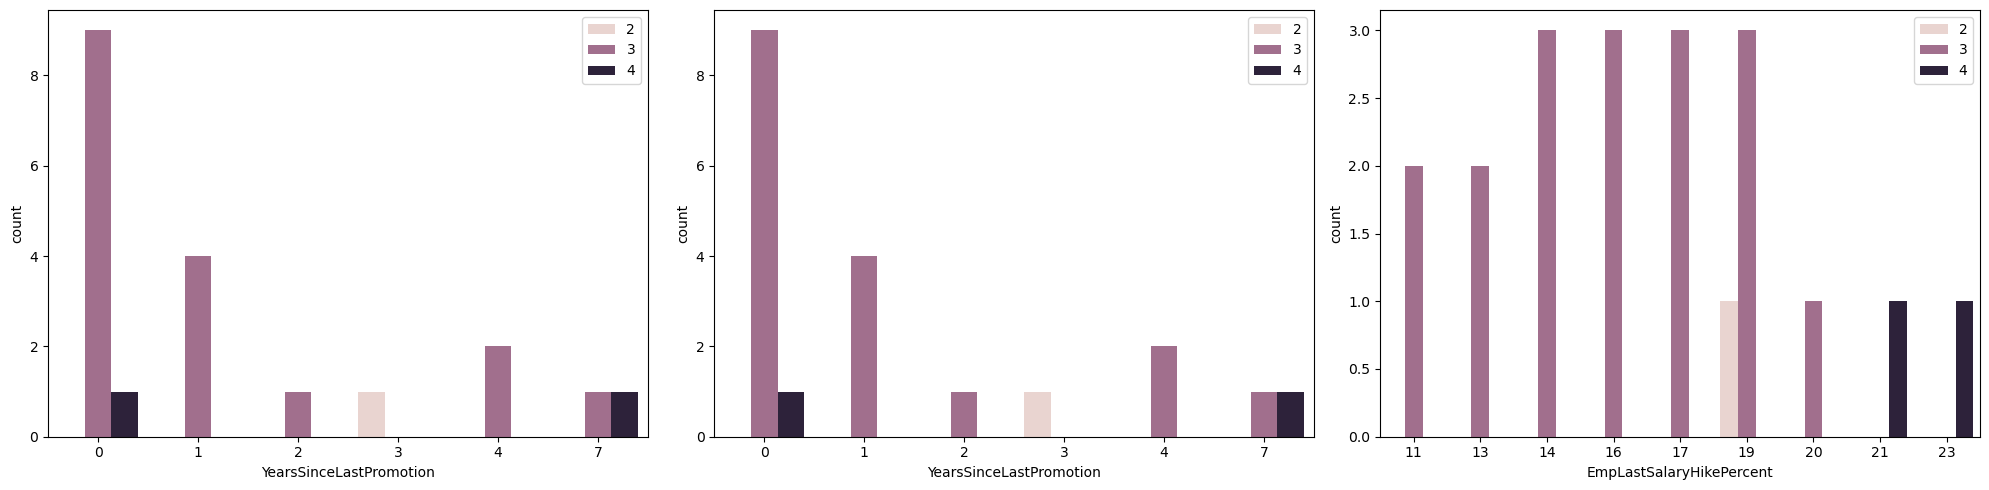

In [39]:
Data_science = data[data.EmpDepartment == 'Data Science']
plots(Data_science)

In [40]:
#checking the number of categories present in each categorical features
data.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

EmpNumber                  1200
Gender                        2
EducationBackground           6
MaritalStatus                 3
EmpDepartment                 6
EmpJobRole                   19
BusinessTravelFrequency       3
OverTime                      2
Attrition                     2
dtype: int64

### Insight 2 : Top 3 Important Factors effecting employee performance

In [42]:
data.drop('EmpNumber',inplace=True,axis=1)

In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#encoding the categorical variables.
categ=['Gender',
'EducationBackground',
'MaritalStatus',
'EmpDepartment',
'EmpJobRole',
'BusinessTravelFrequency',
'OverTime' ,
'Attrition']
for col in categ:
    data[col]=le.fit_transform(data[col])

In [44]:
data.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,1,2,2,5,13,2,10,3,4,...,4,10,2,2,10,7,0,8,0,3
1,47,1,2,2,5,13,2,14,4,4,...,4,20,2,3,7,7,1,7,0,3
2,40,1,1,1,5,13,1,5,4,4,...,3,20,2,3,18,13,1,12,0,4
3,41,1,0,0,3,8,2,10,4,2,...,2,23,2,2,21,6,12,6,0,3
4,60,1,2,2,5,13,2,16,4,1,...,4,10,1,3,2,2,2,2,0,3


In [45]:
data.columns

Index(['Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

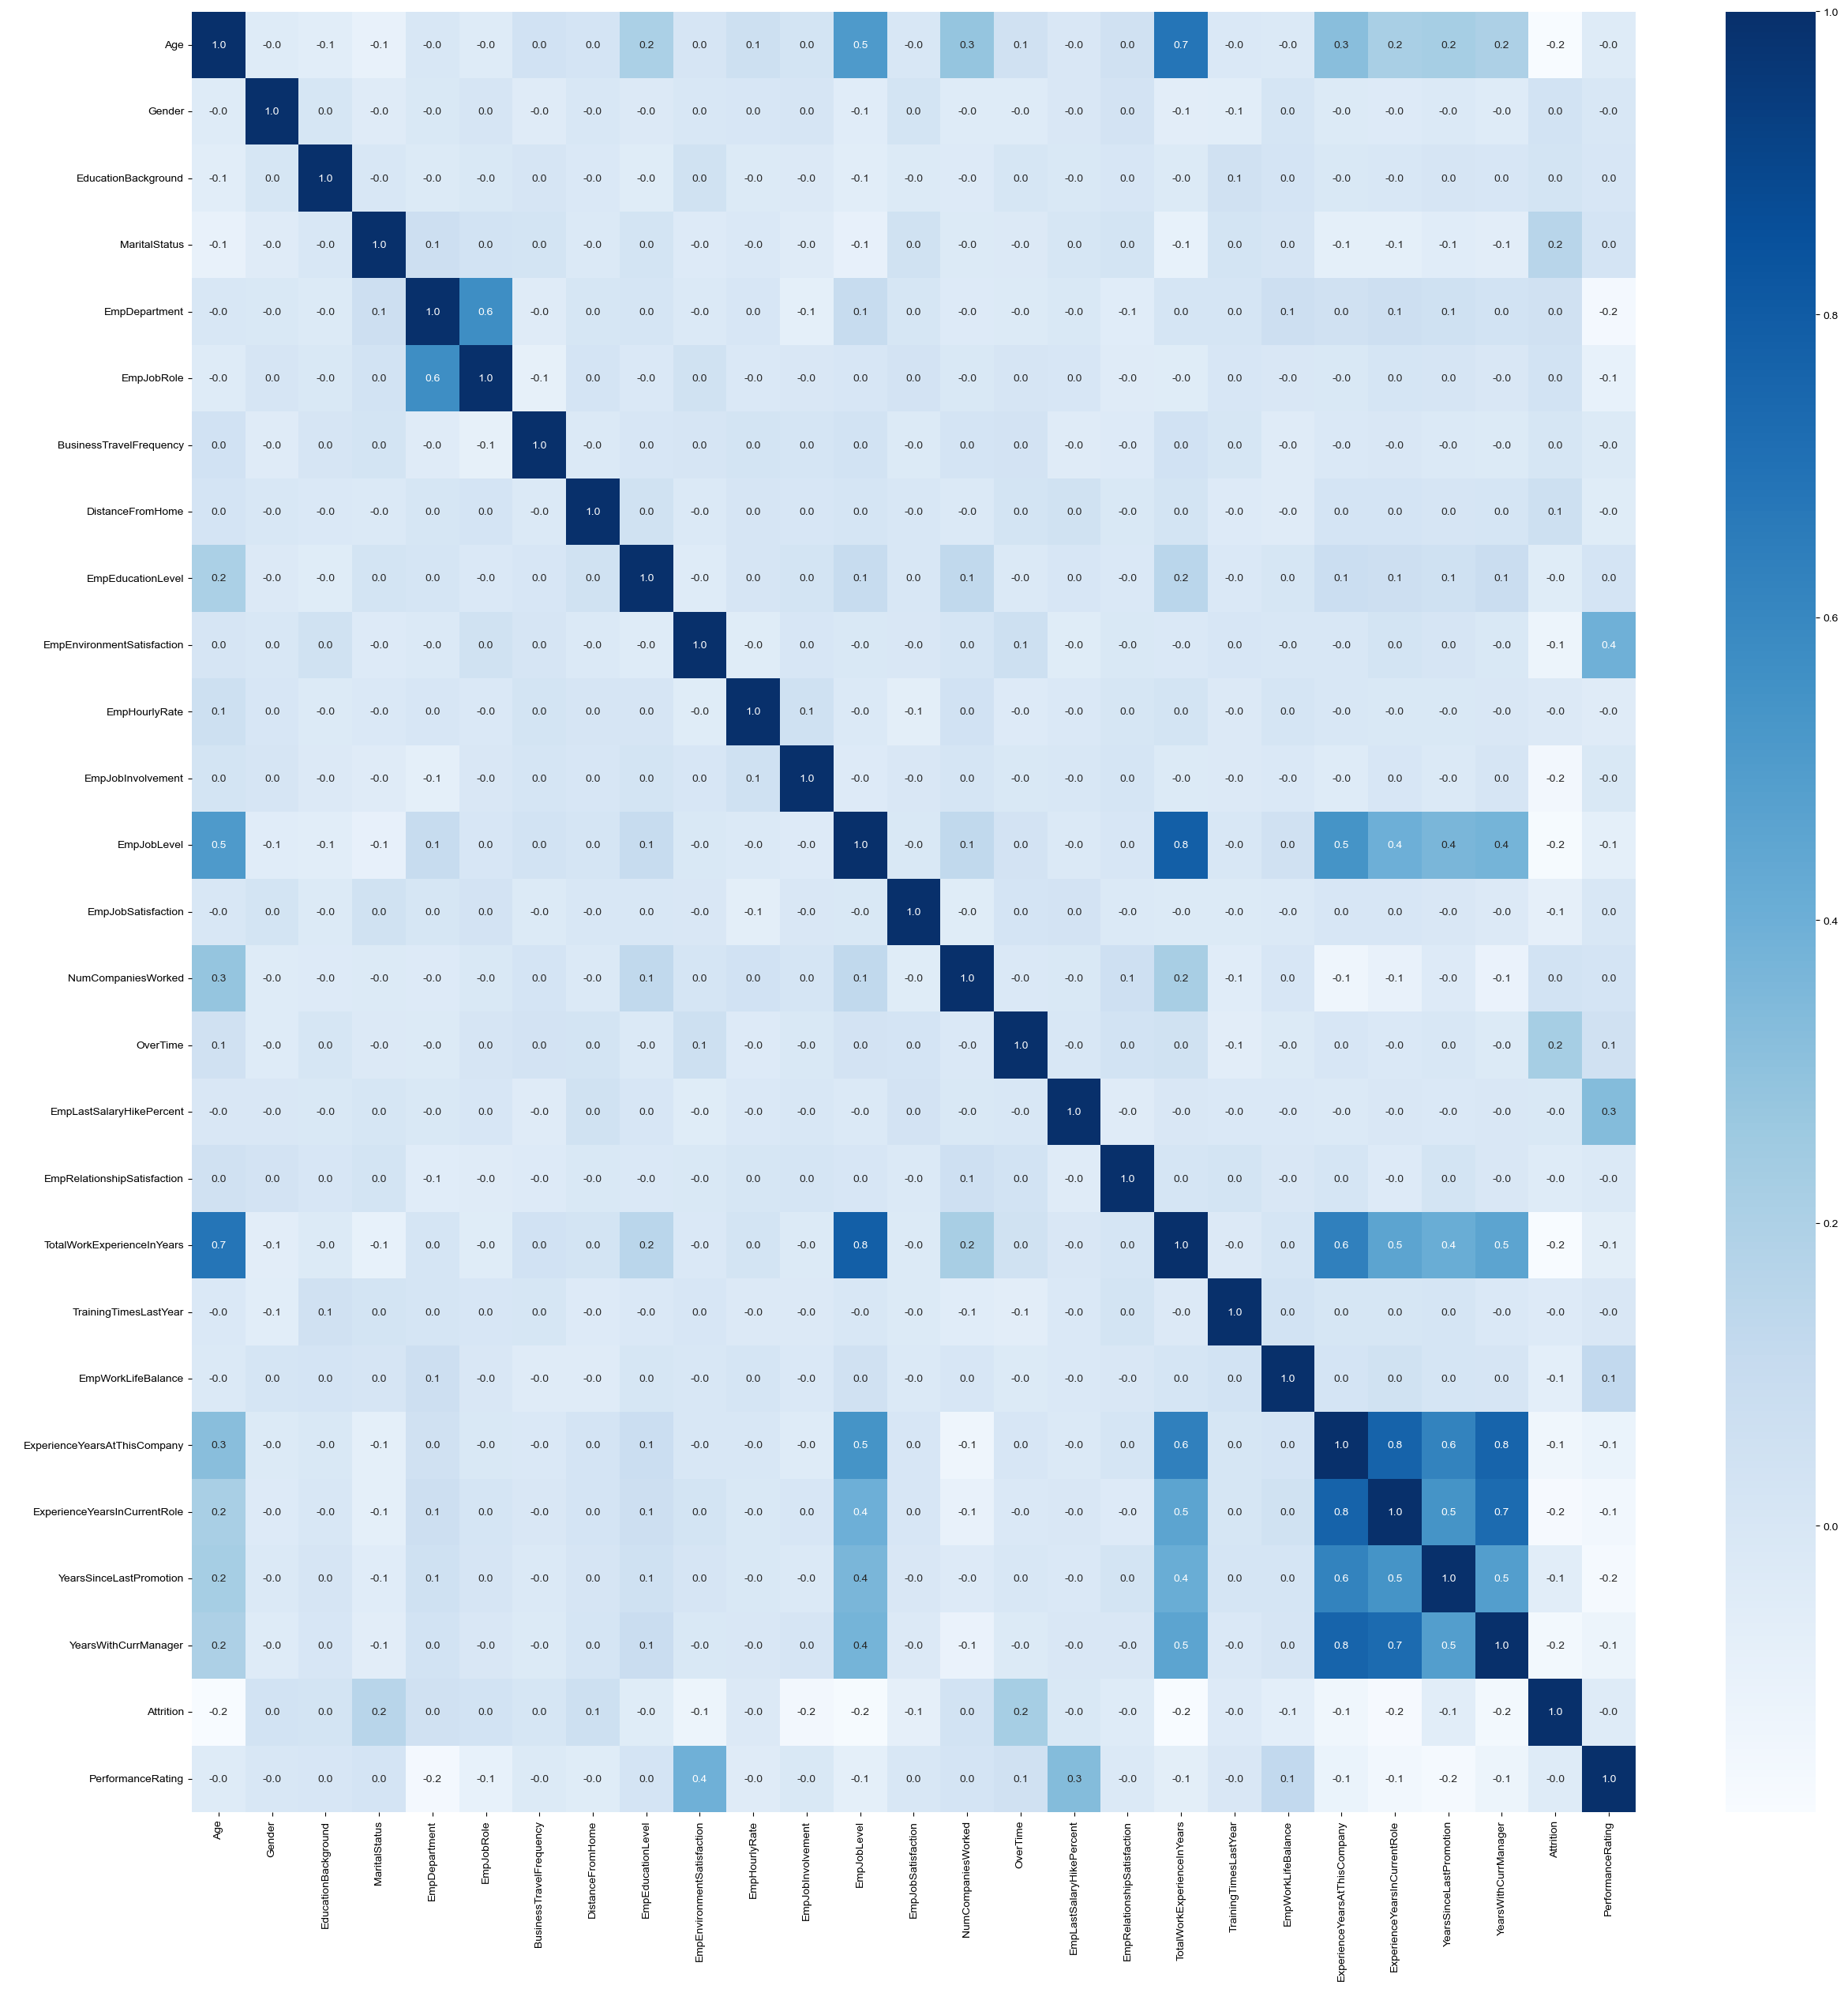

In [46]:
plt.figure(figsize=(26, 26))
sns.heatmap(data.corr(), annot=True, fmt= '.1f', cmap="Blues")
sns.set(font_scale=2.25)
plt.tight_layout()
plt.show()

In [47]:
data.corr()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
Age,1.000000,-0.040107,-0.055905,-0.098368,-0.000104,-0.037665,0.040579,0.020937,0.207313,0.013814,...,0.049749,0.680886,-0.016053,-0.019563,0.318852,0.217163,0.228199,0.205098,-0.189317,-0.040164
Gender,-0.040107,1.000000,0.009922,-0.042169,-0.010925,0.011332,-0.043608,-0.001507,-0.022960,0.000033,...,0.030707,-0.061055,-0.057654,0.015793,-0.030392,-0.031823,-0.021575,-0.036643,0.035758,-0.001780
EducationBackground,-0.055905,0.009922,1.000000,-0.001097,-0.026874,-0.012325,0.012382,-0.013919,-0.047978,0.045028,...,0.005652,-0.027929,0.051596,0.022890,-0.009887,-0.003215,0.014277,0.002767,0.027161,0.005607
MaritalStatus,-0.098368,-0.042169,-0.001097,1.000000,0.067272,0.038023,0.028520,-0.019148,0.026737,-0.032467,...,0.026410,-0.093537,0.026045,0.014154,-0.075728,-0.076663,-0.052951,-0.061908,0.162969,0.024172
EmpDepartment,-0.000104,-0.010925,-0.026874,0.067272,1.000000,0.568973,-0.045233,0.007707,0.019175,-0.019237,...,-0.050286,0.016065,0.016438,0.068875,0.047677,0.069602,0.052315,0.033850,0.048006,-0.162615
EmpJobRole,-0.037665,0.011332,-0.012325,0.038023,0.568973,1.000000,-0.086251,0.022939,-0.016792,0.044612,...,-0.043067,-0.049529,0.004452,-0.007519,-0.009047,0.019383,0.012190,-0.004504,0.037508,-0.096209
BusinessTravelFrequency,0.040579,-0.043608,0.012382,0.028520,-0.045233,-0.086251,1.000000,-0.020935,0.002064,0.012267,...,-0.032705,0.042736,0.006720,-0.040969,-0.015029,-0.006541,-0.020824,-0.028073,0.007217,-0.031025
DistanceFromHome,0.020937,-0.001507,-0.013919,-0.019148,0.007707,0.022939,-0.020935,1.000000,0.045856,-0.017719,...,-0.009509,0.027306,-0.032082,-0.044788,0.021908,0.019898,0.013246,0.017860,0.063248,-0.046142
EmpEducationLevel,0.207313,-0.022960,-0.047978,0.026737,0.019175,-0.016792,0.002064,0.045856,1.000000,-0.037103,...,-0.016690,0.151062,-0.013674,0.010276,0.076332,0.066672,0.054313,0.088988,-0.049118,0.020529
EmpEnvironmentSatisfaction,0.013814,0.000033,0.045028,-0.032467,-0.019237,0.044612,0.012267,-0.017719,-0.037103,1.000000,...,-0.010504,-0.012894,0.001192,-0.000262,-0.000561,0.025491,0.010732,-0.011702,-0.123490,0.395561


In [48]:
corr_matrix = data.corr()
corr_matrix["PerformanceRating"].sort_values(ascending=False)

PerformanceRating               1.000000
EmpEnvironmentSatisfaction      0.395561
EmpLastSalaryHikePercent        0.333722
EmpWorkLifeBalance              0.124429
OverTime                        0.050206
MaritalStatus                   0.024172
NumCompaniesWorked              0.020980
EmpEducationLevel               0.020529
EducationBackground             0.005607
EmpJobSatisfaction              0.000606
Gender                         -0.001780
TrainingTimesLastYear          -0.005443
EmpJobInvolvement              -0.010539
EmpRelationshipSatisfaction    -0.019502
BusinessTravelFrequency        -0.031025
Attrition                      -0.039796
Age                            -0.040164
EmpHourlyRate                  -0.043116
DistanceFromHome               -0.046142
TotalWorkExperienceInYears     -0.068141
EmpJobLevel                    -0.076632
EmpJobRole                     -0.096209
ExperienceYearsAtThisCompany   -0.111645
YearsWithCurrManager           -0.122313
ExperienceYearsI

we can observe both negatively and positively correlated factors in the heat map. So the top three factors that impacts on employee performance are:
- Employee Environment Satisfaction
- Employee Last Salary Hike Percent
- Employee Work-Life Balance

## iii) TRAINING AND BUILDING THE MODEL:

### Insight 3 : A trained model which can predict the employee performance based on factors as inputs, this will be used to hire employees

In [52]:
data.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,1,2,2,5,13,2,10,3,4,...,4,10,2,2,10,7,0,8,0,3
1,47,1,2,2,5,13,2,14,4,4,...,4,20,2,3,7,7,1,7,0,3
2,40,1,1,1,5,13,1,5,4,4,...,3,20,2,3,18,13,1,12,0,4
3,41,1,0,0,3,8,2,10,4,2,...,2,23,2,2,21,6,12,6,0,3
4,60,1,2,2,5,13,2,16,4,1,...,4,10,1,3,2,2,2,2,0,3


Splitting the data into features (x) and target variable (y)

In [54]:
x=data.iloc[:,:-1]
y=data['PerformanceRating']

In [55]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.25, random_state=42)

In [56]:
x_train.shape

(900, 26)

In [57]:
x_test.shape

(300, 26)

In [58]:
y_train.shape

(900,)

In [59]:
y_test.shape

(300,)

## 1) LOGISTIC REGRESSION:

In [61]:
from sklearn.linear_model import LogisticRegression
le = LogisticRegression()
le_fit = le.fit(x_train, y_train)
le_predict = le_fit.predict(x_test)

In [62]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
print('Accuracy Score: \n', accuracy_score(y_test, le_predict))
print('classification Report: \n', classification_report(y_test, le_predict))
print('confusion Matrix: \n', confusion_matrix(y_test, le_predict))

Accuracy Score: 
 0.7966666666666666
classification Report: 
               precision    recall  f1-score   support

           2       0.51      0.51      0.51        37
           3       0.85      0.90      0.87       232
           4       0.63      0.39      0.48        31

    accuracy                           0.80       300
   macro avg       0.67      0.60      0.62       300
weighted avg       0.79      0.80      0.79       300

confusion Matrix: 
 [[ 19  17   1]
 [ 18 208   6]
 [  0  19  12]]


It shows accuracy of 80%

## 2) DECISION TREE:

In [65]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt_fit = dt.fit(x_train, y_train)
dt_predict = dt_fit.predict(x_test)

In [66]:
print('Accuracy Score: \n', accuracy_score(y_test, dt_predict))
print('classification Report: \n', classification_report(y_test, dt_predict))
print('confusion Matrix: \n', confusion_matrix(y_test, dt_predict))

Accuracy Score: 
 0.86
classification Report: 
               precision    recall  f1-score   support

           2       0.70      0.76      0.73        37
           3       0.94      0.89      0.91       232
           4       0.60      0.77      0.68        31

    accuracy                           0.86       300
   macro avg       0.75      0.81      0.77       300
weighted avg       0.87      0.86      0.86       300

confusion Matrix: 
 [[ 28   8   1]
 [ 11 206  15]
 [  1   6  24]]


It shows accuracy of 87%

## 3) RANDOM FOREST:

In [69]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_fit = rf.fit(x_train, y_train)
rf_predict = rf_fit.predict(x_test)

In [70]:
print('Accuracy Score: \n', accuracy_score(y_test, rf_predict))
print('classification Report: \n', classification_report(y_test, rf_predict))
print('confusion Matrix: \n', confusion_matrix(y_test, rf_predict))

Accuracy Score: 
 0.9233333333333333
classification Report: 
               precision    recall  f1-score   support

           2       0.78      0.86      0.82        37
           3       0.94      0.96      0.95       232
           4       0.96      0.74      0.84        31

    accuracy                           0.92       300
   macro avg       0.89      0.85      0.87       300
weighted avg       0.93      0.92      0.92       300

confusion Matrix: 
 [[ 32   5   0]
 [  9 222   1]
 [  0   8  23]]


It shows accuracy of 94%

## 4) NAIVES BAYLES BERNOULLI:

In [73]:
from sklearn.naive_bayes import BernoulliNB
b = BernoulliNB()
b_fit = b.fit(x_train,y_train)
b_predict = b_fit.predict(x_test)

In [74]:
print('Accuracy Score: \n', accuracy_score(y_test, b_predict))
print('classification Report: \n', classification_report(y_test, b_predict))
print('confusion Matrix: \n', confusion_matrix(y_test, b_predict))

Accuracy Score: 
 0.7533333333333333
classification Report: 
               precision    recall  f1-score   support

           2       0.00      0.00      0.00        37
           3       0.77      0.97      0.86       232
           4       0.00      0.00      0.00        31

    accuracy                           0.75       300
   macro avg       0.26      0.32      0.29       300
weighted avg       0.59      0.75      0.66       300

confusion Matrix: 
 [[  0  37   0]
 [  1 226   5]
 [  0  31   0]]


It shows accuracy of 75%

## 5) K NEAREST:

In [77]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10,metric='euclidean')
knn_fit = knn.fit(x_train,y_train)
knn_predict = knn_fit.predict(x_test)

In [78]:
print('Accuracy Score: \n', accuracy_score(y_test, knn_predict))
print('classification Report: \n', classification_report(y_test, knn_predict))
print('confusion Matrix: \n', confusion_matrix(y_test, knn_predict))

Accuracy Score: 
 0.75
classification Report: 
               precision    recall  f1-score   support

           2       0.24      0.11      0.15        37
           3       0.79      0.95      0.86       232
           4       0.33      0.03      0.06        31

    accuracy                           0.75       300
   macro avg       0.45      0.36      0.36       300
weighted avg       0.67      0.75      0.69       300

confusion Matrix: 
 [[  4  32   1]
 [ 11 220   1]
 [  2  28   1]]


it shows accuracy of 75%

## 6) ARTIFICIAL NEURAL NETWORK: 

In [81]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,100,100),batch_size=10,learning_rate_init=0.01,max_iter=2000,random_state=10)
mlp_fit = mlp.fit(x_train,y_train)

In [82]:
mlp_predict = mlp_fit.predict(x_test)

In [83]:
print('Accuracy Score: \n', accuracy_score(y_test, mlp_predict))
print('classification Report: \n', classification_report(y_test, mlp_predict))
print('confusion Matrix: \n', confusion_matrix(y_test, mlp_predict))

Accuracy Score: 
 0.8166666666666667
classification Report: 
               precision    recall  f1-score   support

           2       0.69      0.54      0.61        37
           3       0.83      0.95      0.89       232
           4       0.67      0.13      0.22        31

    accuracy                           0.82       300
   macro avg       0.73      0.54      0.57       300
weighted avg       0.80      0.82      0.78       300

confusion Matrix: 
 [[ 20  17   0]
 [  9 221   2]
 [  0  27   4]]


It shows accuracy of 82%

## 7) XGBoost:

In [86]:
# model doesn't get trained with wrong labels, so subtracting with 2 makes the label as [0,1,2]
y_train = y_train - 2
y_test = y_test - 2

In [87]:
### Before running the above cell i got this error,
### ValueError: Invalid classes inferred from unique values of `y`. Expected: [0 1 2], got [2 3 4]

In [88]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_fit = xgb.fit(x_train,y_train)

In [89]:
xgb_predict = xgb_fit.predict(x_test)

In [90]:
print('Accuracy Score: \n', accuracy_score(y_test, xgb_predict))
print('classification Report: \n', classification_report(y_test, xgb_predict))
print('confusion Matrix: \n', confusion_matrix(y_test, xgb_predict))

Accuracy Score: 
 0.92
classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.86      0.83        37
           1       0.94      0.95      0.95       232
           2       0.88      0.74      0.81        31

    accuracy                           0.92       300
   macro avg       0.88      0.85      0.86       300
weighted avg       0.92      0.92      0.92       300

confusion Matrix: 
 [[ 32   5   0]
 [  8 221   3]
 [  0   8  23]]


It shows accuracy score of 92%

So far the accuracies of the used models are,

- Logistic Regression = 80%
- DecisionTree = 87%
- RandomForest = 94%
- Bernoulli = 75%
- KNN = 75%
- MLP = 82%
- XGBoost = 92%

In [169]:
import joblib
joblib.dump(rf_fit, 'random_forest_model.pkl')

['random_forest_model.pkl']

Exporting the best model

### Insight 4 : Recommendations to improve the employee performance based on insights from analysis.

- From the analysis, we found that variables such as Employee Environment Satisfaction, Last Salary Hike Percent, Work-Life Balance, Experience Years in Current Role, and Overtime are closely related to performance ratings. Based on these insights, the company should focus on these areas to improve overall employee performance.

- In conclusion, providing a better work environment can significantly boost employee performance. Additionally, offering regular salary hikes and supporting a healthy work-life balance will help employees stay motivated and perform at their best

## iv) SUMMARY

- In this project, we applied algorithms such as Logistic Regression, Decision Tree, Random Forest, Bernoulli, KNN, MLP and XGBoost classifier to evaluate model accuracy. Among these, Random Forest achieved the highest accuracy of 94%